<a href="https://colab.research.google.com/github/violeta-angulo-data/movilidad-urbana/blob/main/analisis_plan_telecom_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage¿
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
**¿Qué columnas tienen valores faltantes y en qué proporción?**
  Para el **df users,** las columnas 'city' y 'churn_date' presentan valores faltantes; 11.7% y 88.35%, respectivamente, lo cual no representa un porcentaje alarmante para 'city', mientras que 'churn_date' mantiene activo al 88.35% de sus clientes. Un buen indicador de satisfacción del cliente.
  En el caso del **df usage,** columnas como 'date', 'duration' y 'length' presentan valores faltantes en cifras alarmantes; 0.1%,55.19% y 44.74%, respectivamente.
  
  **Indica qué harías: ¿imputar, eliminar, ignorar?** Para casos puntuales como el **df usage** 'duration' y 'length' representan unidades que no siempre corresponden a la lógica del negocio, por lo cual un 55.19% y 44.74% se puede pasar por alto sin correr el riesgo de contaminar el análisis, algo similar ocurre con 'date' representa un valor nulo tan bajo que es intrascendente, por lo que se puede mantener.
  Para **df users** la columna 'city' los valores nulos se agruparán como "desconocido" para no perder información valiosa sobre esos clientes.
  mientras que la columna 'churn date' un porcentaje alto de nulos representa un nivel alto de satisfacción.


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
users["age"].describe()

count    4000.000000
mean       33.739750
std       123.232257
min      -999.000000
25%        32.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

- La columna `user_id` no corresponde a este breve análisis exploratorio, puesto que no aporta un valor estadístico significativo
- La columna `age` presenta una desviación estándar de 123.23, que corresponde a un "valor centinela" pues se aleja mucho de la media

In [ ]:
users[users["age"] == -999]

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
12,10012,Mariana,Lopez,-999,Medellín,2022-01-04 06:51:34.973743435,Premium,NaN
146,10146,Carlos,Ramirez,-999,GDL,2022-02-09 23:27:35.513878470,Basico,NaN
171,10171,Carlos,Lopez,-999,Medellín,2022-02-16 19:45:03.375843961,Basico,"1,72368E+18"
243,10243,Ana,Gomez,-999,MTY,2022-03-08 12:54:33.218304576,Premium,NaN
297,10297,Carlos,Gomez,-999,Medellín,2022-03-23 07:46:40.600150038,Basico,NaN
377,10377,Mariana,Torres,-999,Cali,2022-04-14 05:30:33.758439610,Premium,NaN
456,10456,Mateo,Ramirez,-999,CDMX,2022-05-05 20:40:09.002250564,Basico,"1,72653E+18"
509,10509,Luis,Gomez,-999,CDMX,2022-05-20 08:57:58.469617406,Basico,NaN
526,10526,Sofia,Gomez,-999,MTY,2022-05-25 00:41:03.015753940,Basico,NaN
552,10552,Mateo,Ramirez,-999,GDL,2022-06-01 03:32:48.792198050,Basico,NaN


In [ ]:
# Se realizó un conteo de los valores sentinelas en la columna 'age'
(users["age"] == -999).sum()

55

In [ ]:
# explorar columnas numéricas de usage
usage[["duration","length"]].describe()

,duration,length
count,17924.000000,22104.000000
mean,5.202237,52.127398
std,6.842701,56.611183
min,0.000000,0.000000
25%,1.437500,37.000000
50%,3.500000,50.000000
75%,6.990000,64.000000
max,120.000000,1490.000000


- Las columnas `id` y `user_id` nuevamente no aportan valor significativo
al análisis
- La columna `duration` muestra valores relativamente estables entre su media y mediana; estas son 5.2 y 3.5 (minutos), respectivamente, y un máximo de 120. Se podría tratar de un posible outlier o de que se alcanzó el límite técnico del sistema, pero esto es solo un diagnóstico preliminar. Asimismo, `length` con su media de 52 y mediana de 50, igual se mantiene en un rango normal y con su máximo de 1490 (caracteres) podría señalar un posible outlier.

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(users[col].unique())
    print(users[col].value_counts())
print(f"Valores únicos de {col}")

['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
['Basico' 'Premium']
Basico     2595
Premium    1405
Name: plan, dtype: int64
Valores únicos de plan


- La columna `city` ...**NO OLVIDAR COMENTARIOS AQUÍ**
- La columna `plan` ...**NO OLVIDAR COMENTARIOS AQUÍ**

In [ ]:
# explorar columna categórica de usage
print(usage['type'].unique())
print(usage['type'].value_counts())

['call' 'text']
text    22092
call    17908
Name: type, dtype: int64


- La columna `type` ...
COMPLETAR PÁRRAFO AQUÍ **NO OLVIDAR**

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
print(users['reg_date'].isna().sum())
users['reg_date'].dt.year >= 2025
users.loc[users['reg_date'].dt.year >= 2025, 'reg_date' ] = pd.NaT

0


In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [ ]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

2024.0    1330
2023.0    1316
2022.0    1314
Name: reg_date, dtype: int64

En `reg_date`, los tres años tienen conteos similares, entre 1314 y 1330, esto es un buen indicador pues se trata de una distribución uniforme.

In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`, aparecen únicamente registros del 2024; esto indica que este año concentra el uso de servicios de todos los usuarios, independientemente de su año de registro.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- Aparecieron algunos registros de 2026 en `reg_date` de `users` los cuales fueron posteriormente se trataron como valores nulos
- De lo contrario, en `date` de `usage` solo aparecieron registros de 2024

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users["age"][users["age"] != -999].median()
users['age'] = users["age"].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print("cantidad de nulos para city actualizada")
print(users['city'].isna().sum())

cantidad de nulos para city actualizada
565


In [ ]:
# Marcar fechas futuras como NA para reg_date
print("cantidad de fechas nulas y/o fuera de rango:")
print(users['reg_date'].isna().sum())

# Verificar cambios
print(users['reg_date'].dt.year.value_counts(dropna=False).sort_index())

cantidad de fechas nulas y/o fuera de rango:
40
2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().mean())

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().mean())

type
call    0.99933
text    0.00000
Name: length, dtype: float64

**ESCRIBIR AQUÍ EL DIAGNÓSTICO, NO OLVIDAR**
Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

### 🧩Paso 4: Summary statistics de uso por usuario

5.1. 4.1 Agrupación por comportamiento de uso

**🎯Objetivo: Resumir las variables clave de la tabla usage por usuario,creando métricas que representen su comportamiento real de uso histórico.**

**Instrucciones**

Construye una tabla agregada de usage por user_id que incluya:
- número total de mensajes
- número total de llamadas
- total de minutos de llamadas

Renombra las columnas para que tengan nombres claros:
- cant_mensajes
- cant_llamadas
- cant_minutos_llamada

Combina esta tabla con users.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg(
    cant_mensajes=('is_text', 'sum'),
    cant_llamadas=('is_call', 'sum'),
    cant_minutos_llamada=('duration', 'sum')
).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='inner')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000
mean,11999.729432,48.138285,5.524381,4.478120,23.317054
std,1154.898108,17.691541,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.500000,33.000000,4.000000,3.000000,11.120000
50%,12000.000000,48.000000,5.000000,4.000000,19.780000
75%,12999.500000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)

Basico     0.648662
Premium    0.351338
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

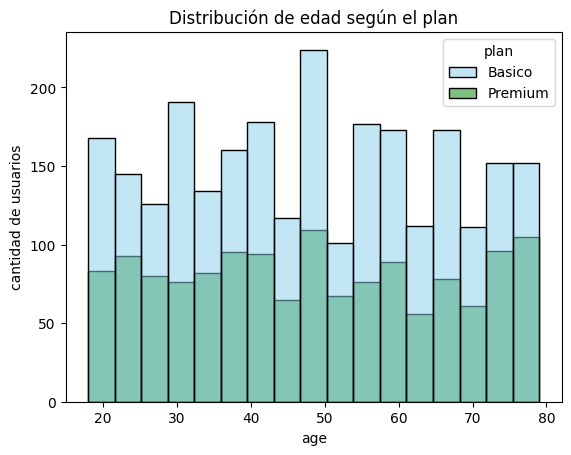

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(data= user_profile, x='age', hue='plan', palette=['skyblue','green'])
plt.title("Distribución de edad según el plan")
plt.ylabel("cantidad de usuarios")
plt.xlabel("age")
plt.show()

💡Insights:
Se puede observar una distribución equilibrada entre el plan Básico y Premium.
el grupo etario más alto es el de 45-50 en el plan Premium

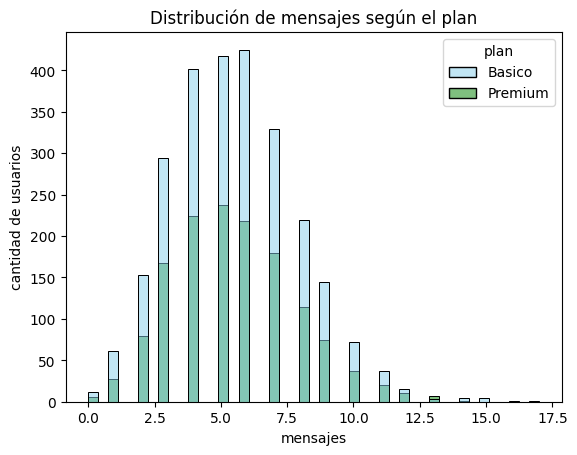

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue','green'])
plt.title("Distribución de mensajes según el plan")
plt.ylabel("cantidad de usuarios")
plt.xlabel("mensajes")
plt.show()

💡Insights:
- ....

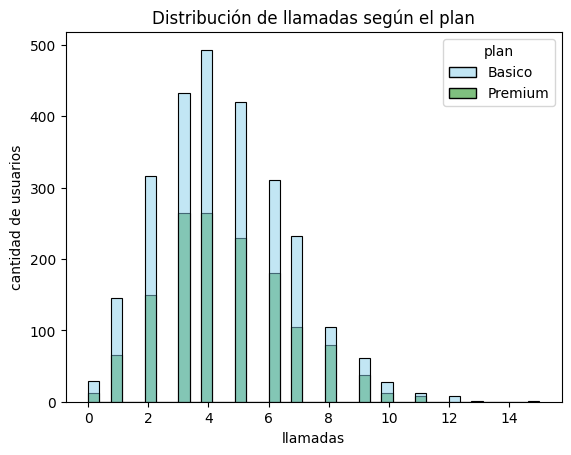

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue','green'])
plt.title("Distribución de llamadas según el plan")
plt.ylabel("cantidad de usuarios")
plt.xlabel("llamadas")
plt.show()

💡Insights:
- Distribución ...

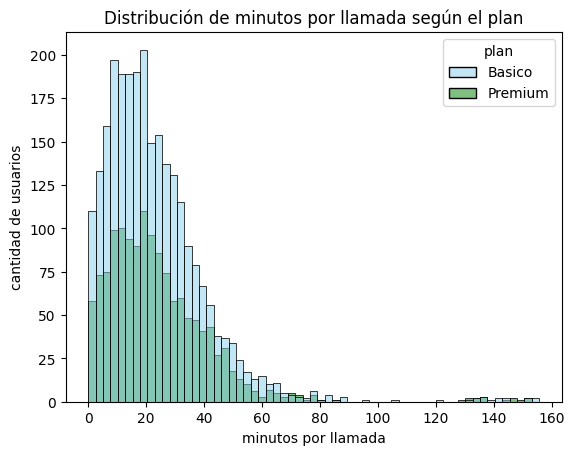

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue','green'])
plt.title("Distribución de minutos por llamada según el plan")
plt.ylabel("cantidad de usuarios")
plt.xlabel("minutos por llamada")
plt.show()

💡Insights:
- ...

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

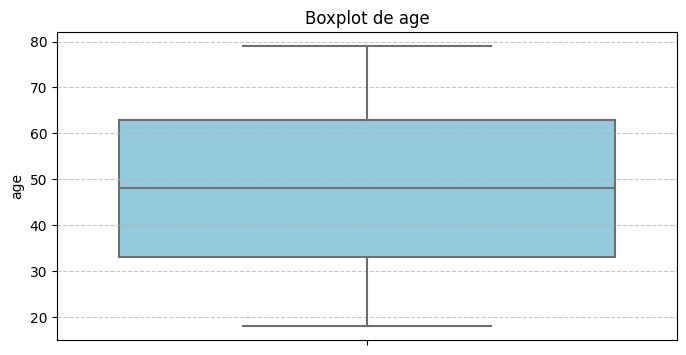

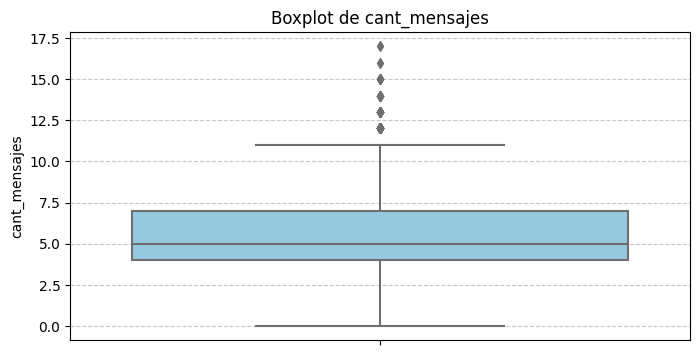

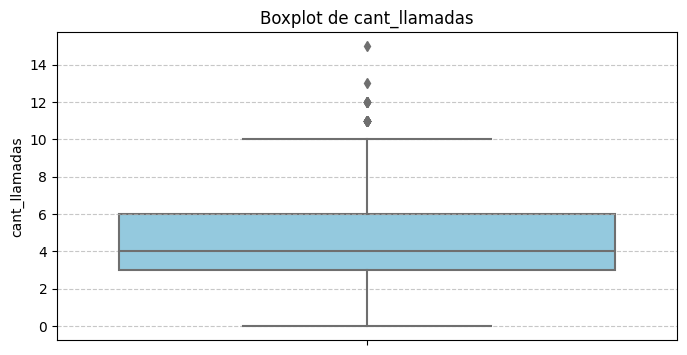

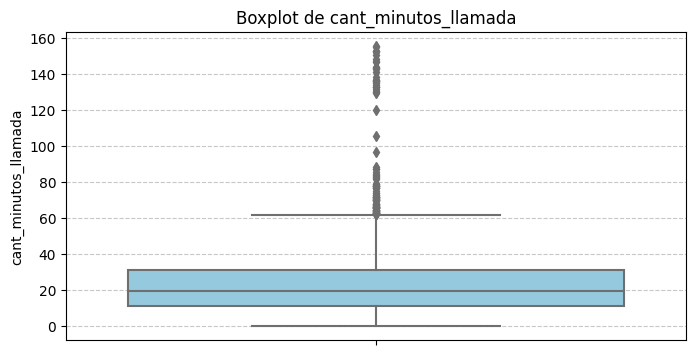

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(y=user_profile[col], color="skyblue")
    plt.title(f"Boxplot de {col}")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

💡Insights:
- Age: Este boxplot no presenta ningún outlier
- cant_mensajes: Se puede observar una serie de 6 outliers, distribuidos de forma equidistante en el nivel superior del boxplot
- cant_llamadas: Se pueden observar algunos outliers en el nivel superior; entre los valores de 10 y 14 específicamente
- cant_minutos_llamada: Se puede observar una gran cantidad de outliers que se solapan entre sí en el nivel superior

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes','cant_llamadas','cant_minutos_llamada']
limites = {}

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    limites[col] = (limite_inferior, limite_superior)

In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


**💡Insights:
- cant_mensajes: 17 mensajes es un valor alto aunque plausible, se puede mantener este outlier.
- cant_llamadas: 15 llamadas es un valor muy elevado, se puede prescindir de esta información.
- cant_minutos_llamada: Una llamada de 155 minutos, aunque no es lo común, puede reflejar el comportamiento real de un usuario, por lo que se puede mantener este outlier.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
def clasificar_cliente(fila):
  if fila['cant_llamadas'] < 5 and fila['cant_mensajes'] < 5:
      return 'Bajo uso'
  elif fila['cant_llamadas'] < 10 and fila['cant_mensajes'] < 10:
    return 'Uso medio'
  else:
    return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(clasificar_cliente, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
def clasificar_edad(fila):
  if fila['age'] < 30:
      return 'Joven'
  elif fila['age'] < 60:
    return 'Adulto'
  else:
    return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(clasificar_edad, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

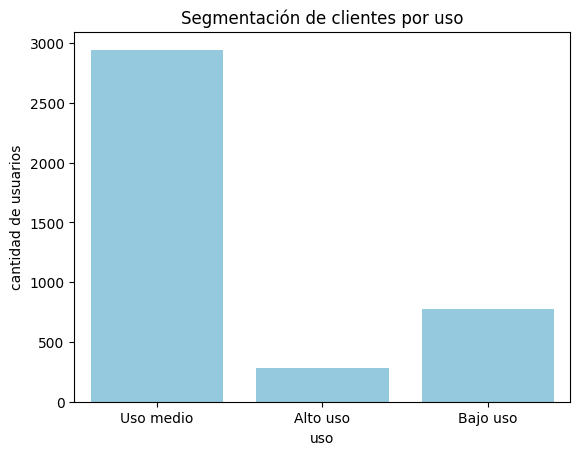

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso', color='skyblue')
plt.title("Segmentación de clientes por uso")
plt.xlabel("uso")
plt.ylabel("cantidad de usuarios")
plt.show()

In [ ]:
# Porcentaje de cada segmento por uso
user_profile['grupo_uso'].value_counts(normalize=True) * 100

Uso medio    73.593398
Bajo uso     19.454864
Alto uso      6.951738
Name: grupo_uso, dtype: float64

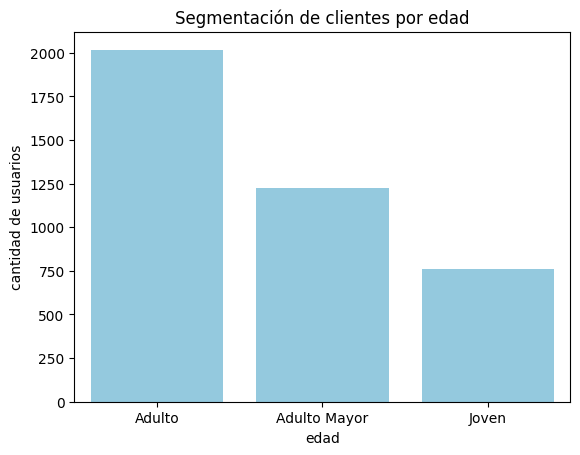

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', color='skyblue')
plt.title("Segmentación de clientes por edad")
plt.xlabel("edad")
plt.ylabel("cantidad de usuarios")
plt.show()

In [ ]:
# Porcentaje de cada segmento por edad
user_profile['grupo_edad'].value_counts(normalize=True) * 100

Adulto          50.437609
Adulto Mayor    30.557639
Joven           19.004751
Name: grupo_edad, dtype: float64

In [ ]:
# Se creó una tabla de correlación entre edad y uso
pd.crosstab(user_profile['grupo_edad'], user_profile['grupo_uso'], normalize='index') * 100

grupo_uso,Alto uso,Bajo uso,Uso medio
grupo_edad,,,
Adulto,7.585523,18.046604,74.367873
Adulto Mayor,6.055646,21.031097,72.913257
Joven,6.710526,20.657895,72.631579


In [ ]:
basico_excede = user_profile[
    (user_profile['cant_minutos_llamada'] > 100) &
    (user_profile['plan'] == 'Basico')
]
print(len(basico_excede))

17



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**

**¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?**

- En 'df users', presentó valores nulos en 'churn_date'; en el contexto de negocio, la ausencia de registros de 'churn_date' (fecha de cancelación) equivale a  clientes activos o satisfechos con el servicio.
  
- También se detectó un error en el registro de valores de 'city', que presentó un 11,7% de valores faltantes, los cuales se imputaron reemplazándolos por NA.

- Asimismo, se encontraron 55 valores sentinels en la columna 'age' que fueron reemplazados:
-999 → se imputó por la mediana.

- En 'reg_date' se encontraron 40 fechas fuera de rango (de 2025 en adelante), las cuales se marcaron como NaT. Considerando que este análisis abarca solo hasta el año 2024.

**¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?**


Se crearon los siguientes segmentos;
- **Segmentación por edad** donde **Adulto** representa el 50,43% de los usuarios y se caracteriza por  superar a la segunda categoría **Adulto mayor** en un 20%.
- **Segmentación por uso**, donde **Uso medio** representa el 73,59% de los usuarios.
- A partir de esto, se puede concluir que no hay correlación entre edad y uso, puesto que la distribución se mantiene similar.
- El patrón de comportamiento no refleja una tendencia hacia un grupo etario en particular. A partir de esto, proponemos mejor reunir esfuerzos en retención de clientes dirigidos al grupo de **uso medio**, que concentra un 73,59% de los usuarios, por lo que procurar este segmento es prioridad, de lo contrario, puede ocasionar un incremento en el churn rate actual de 11,65%, impactando directamente en el segmento más numeroso de clientes.

**¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?**
- El segmento más valioso para ConnectaTel son usuarios de **uso medio**, ya que, como antes se mencionó, conforman un 73,59% del catálogo de clientes.

**¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?**
- Hay outliers de alto impacto en el extremo superior del boxplot de cantidad de minutos de llamada; esto señala que un breve segmento de usuarios del plan Básico consume más minutos de los inicialmente estipulados. Tomando en cuenta lo que pagan adicional a su plan

**¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?**

- Hay un pequeño segmento de usuarios Básico que exceden su uso de minutos; esto representa un gasto extra para ellos y una oportunidad de conversión hacia el plan Premium para ConnectaTel; esto tiene sentido porque reciben un plan que responde mejor a sus necesidades de uso.

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

- Se registró un 11,7% de valores nulos en 'city' de 'df_users' que fueron reemplazados por NA
- 55 sentinels fueron imputadas por la mediana en la columna 'age'
- Se encontraron 40 fechas fuera de rango y se marcaron como NaT.

🔍 **Segmentos por Edad**

- El segmento etario más fuerte fue 'Adulto', con el  50,43% del total de registros; sin embargo, se concluyó que las campañas por edad no son una buena estrategia de ventas.

📊 **Segmentos por Nivel de Uso**

- El segmento más significativo encontrado fue 'Uso medio', que representa el 73,59% de los clientes activos.

➡️ Esto sugiere que ...

Hay una oportunidad de negocios en el segmento para los miembros del plan Básico que exceden su uso.

💡 **Recomendaciones**

- Por lo que se recomienda poner en acción un plan de upsell para este segmento de clientes, migrándolos al plan Premium ya que se adecúa más a sus necesidades de uso.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`